NOTE: Bar Charts categorical data compare karne ke liye hain (jaise Country-wise revenue), Histograms numeric data ka distribution dikhane ke liye (jaise Monetary values kaise spread hain) — Day 42 mein histogram use kar chuke ho, aaj properly seekhenge.

1. Setup:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')
tx = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str}
)
tx['LineTotal'] = tx['Quantity'] * tx['Price']

2. Basic Bar Chart — top 10 countries by revenue:

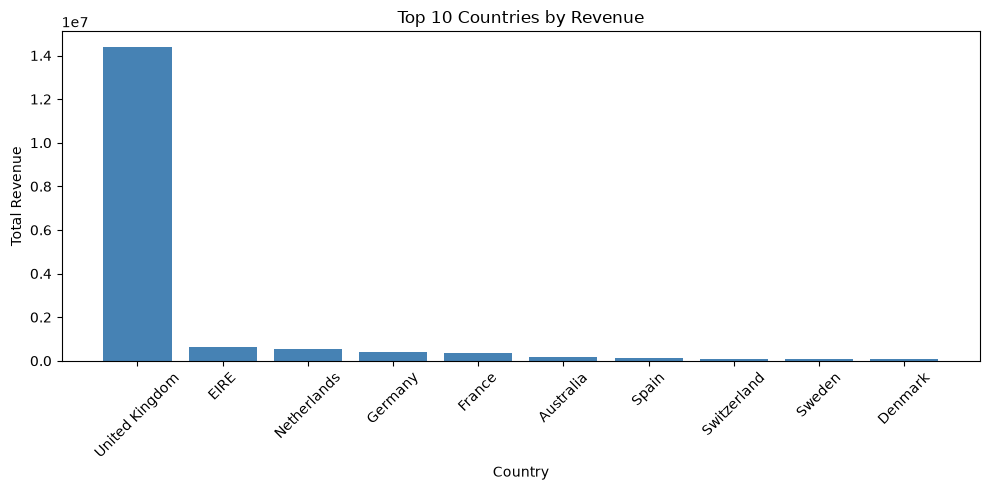

In [2]:
country_revenue = tx.groupby('Country')['LineTotal'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(country_revenue.index, country_revenue.values, color='steelblue')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue')
ax.set_title('Top 10 Countries by Revenue')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

3. Horizontal Bar Chart — jab category names lambe hon, barh() zyada readable hota hai:

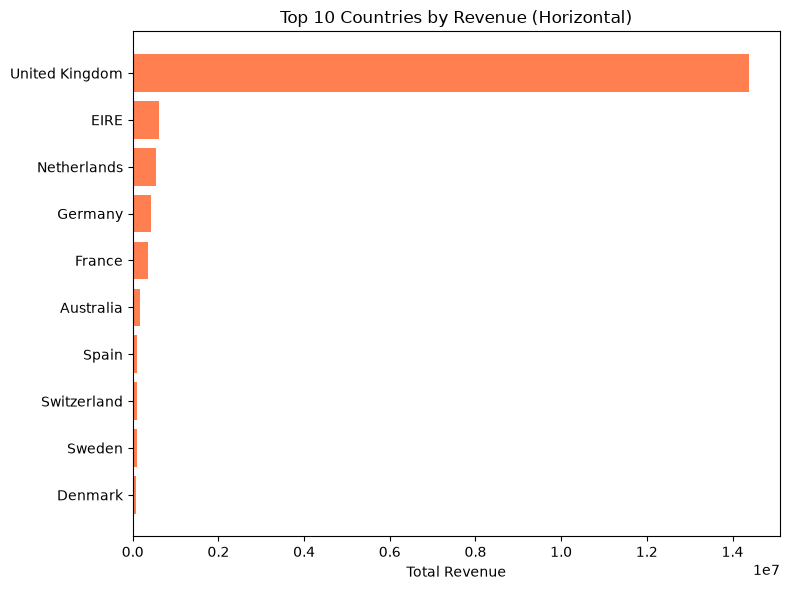

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(country_revenue.index[::-1], country_revenue.values[::-1], color='coral')
ax.set_xlabel('Total Revenue')
ax.set_title('Top 10 Countries by Revenue (Horizontal)')
plt.tight_layout()
plt.show()

note: [::-1] se order reverse kiya taaki sabse bada bar sabse upar dikhe (horizontal bar charts naturally bottom-se-top plot karte hain).

4. Grouped Bar Chart — Churned vs Not-Churned, metrics compare karna:

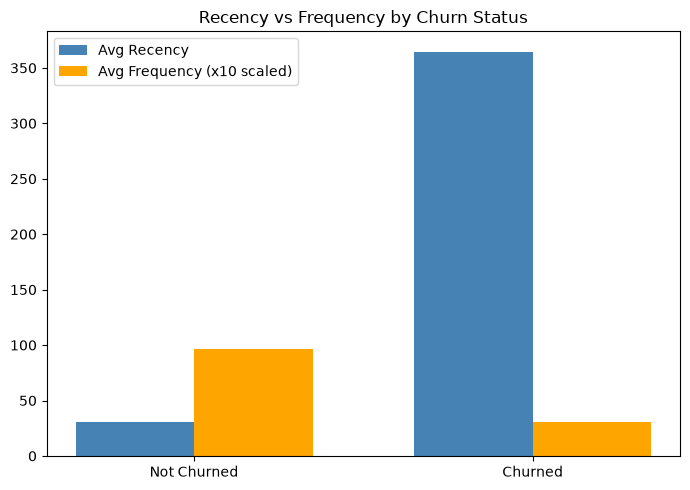

In [4]:
segment_stats = df.groupby('Churned')[['Recency', 'Frequency']].mean()

fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(segment_stats))
width = 0.35

ax.bar([i - width/2 for i in x], segment_stats['Recency'], width, label='Avg Recency', color='steelblue')
ax.bar([i + width/2 for i in x], segment_stats['Frequency']*10, width, label='Avg Frequency (x10 scaled)', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['Not Churned', 'Churned'])
ax.set_title('Recency vs Frequency by Churn Status')
ax.legend()
plt.tight_layout()
plt.show()

Note: Frequency ko *10 scale kiya kyunki Recency (days) aur Frequency (orders) ki units bahut alag hain — agar scale na karein to Frequency bar chart mein nazar hi nahi aayega.

5. Churn count bar chart — simple but important chart (README mein zaroor jayega):

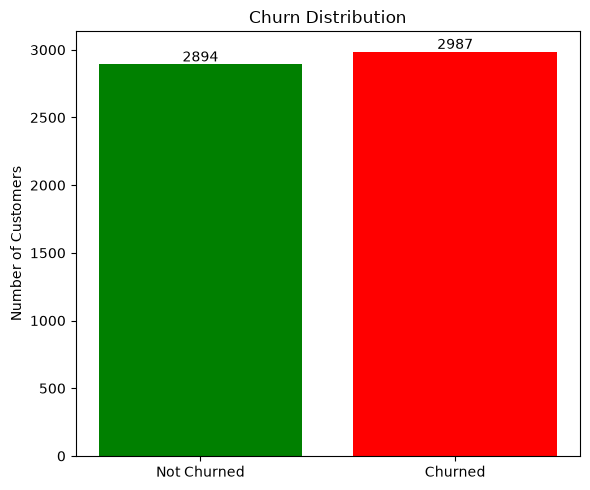

In [5]:
churn_counts = df['Churned'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Not Churned', 'Churned'], churn_counts.values, color=['green', 'red'])
ax.set_ylabel('Number of Customers')
ax.set_title('Churn Distribution')

# Har bar ke upar count label likhna (professional touch)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20, f'{int(height)}', ha='center')
plt.tight_layout()
plt.show()

6. Histogram — basic, Monetary distribution (Day 42 ka revision, ab properly):

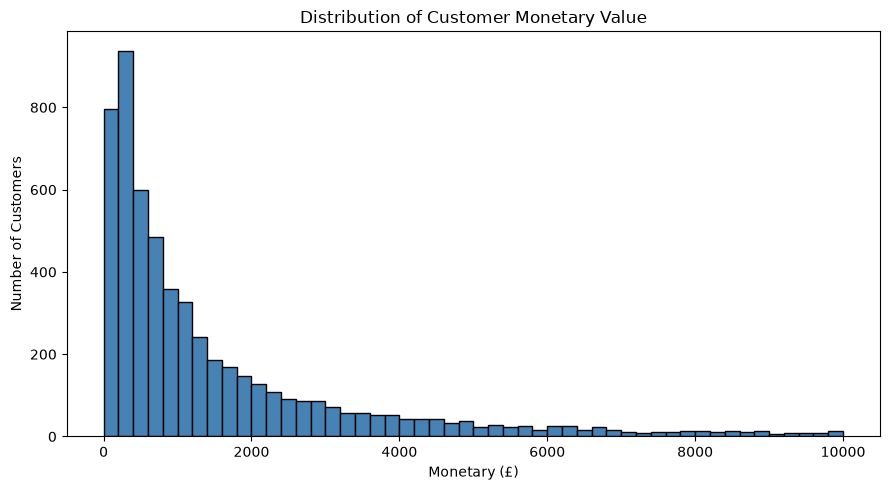

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Monetary'], bins=50, color='steelblue', edgecolor='black', range=(0, 10000))
ax.set_xlabel('Monetary (£)')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Customer Monetary Value')
plt.tight_layout()
plt.show()

7. bins parameter ka asar dekhna — bahut zaroori concept (kam bins = zyada smooth, zyada bins = zyada detail):

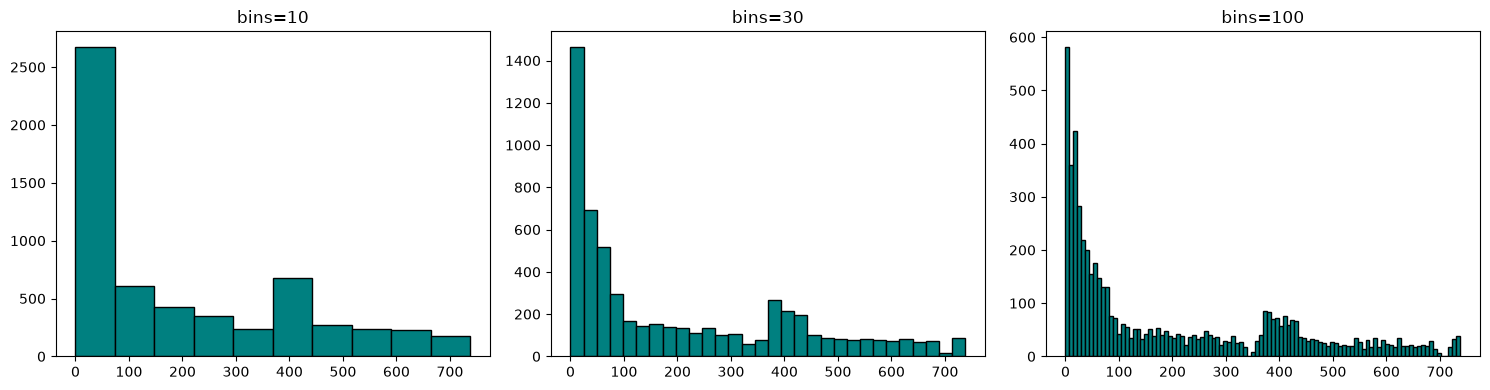

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [10, 30, 100]):
    ax.hist(df['Recency'], bins=b, color='teal', edgecolor='black')
    ax.set_title(f'bins={b}')
plt.tight_layout()
plt.show()

8. Overlapping histograms — Churned vs Not-Churned Recency compare karna:

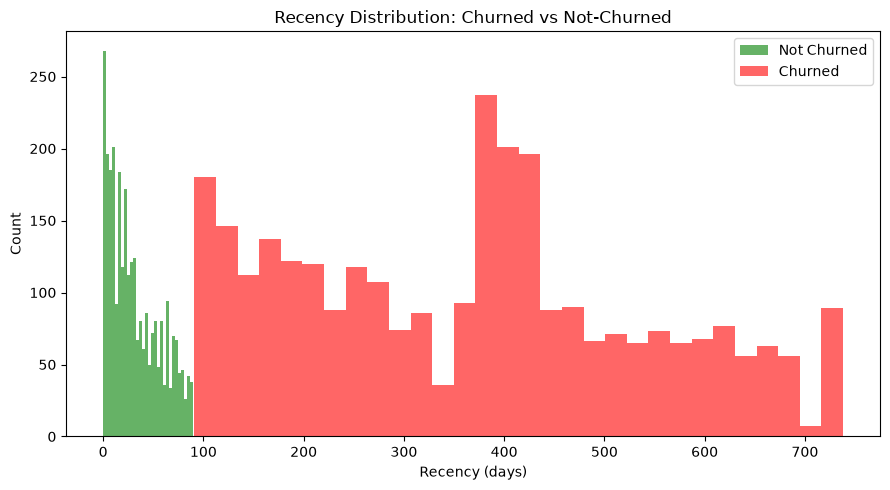

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df[df['Churned']==0]['Recency'], bins=30, alpha=0.6, label='Not Churned', color='green')
ax.hist(df[df['Churned']==1]['Recency'], bins=30, alpha=0.6, label='Churned', color='red')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Count')
ax.set_title('Recency Distribution: Churned vs Not-Churned')
ax.legend()
plt.tight_layout()
plt.show()

practice questions:

1. Bar chart banao jo Top 10 StockCodes dikhaye total Quantity sold ke hisaab se.

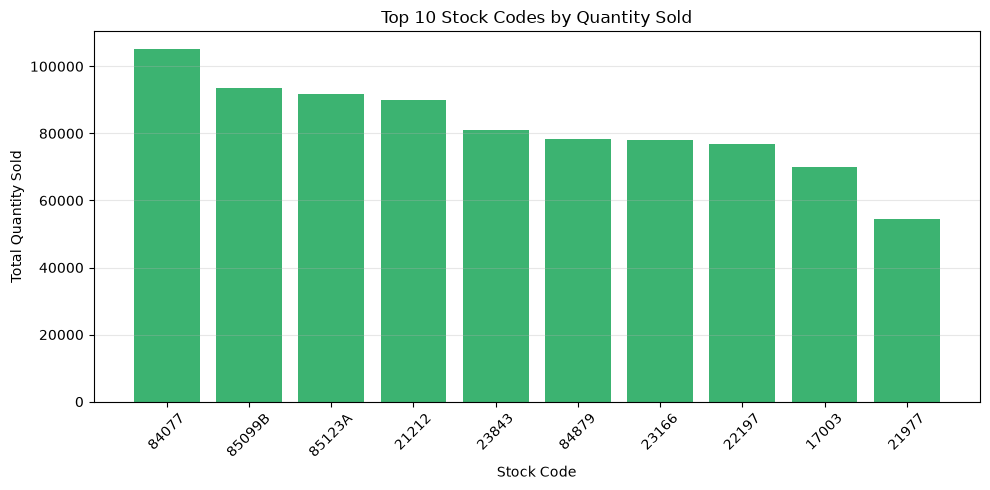

In [9]:
# 1. Top 10 stock codes calculate karo based on Quantity
top_stock = tx.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

# 2. fig, ax style mein bar chart banao
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_stock.index, top_stock.values, color='mediumseagreen')
ax.set_xlabel('Stock Code')
ax.set_ylabel('Total Quantity Sold')
ax.set_title('Top 10 Stock Codes by Quantity Sold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

2. Histogram banao Frequency column ka (bins=30), aur dekho kya yeh bhi right-skewed hai jaisa Monetary.

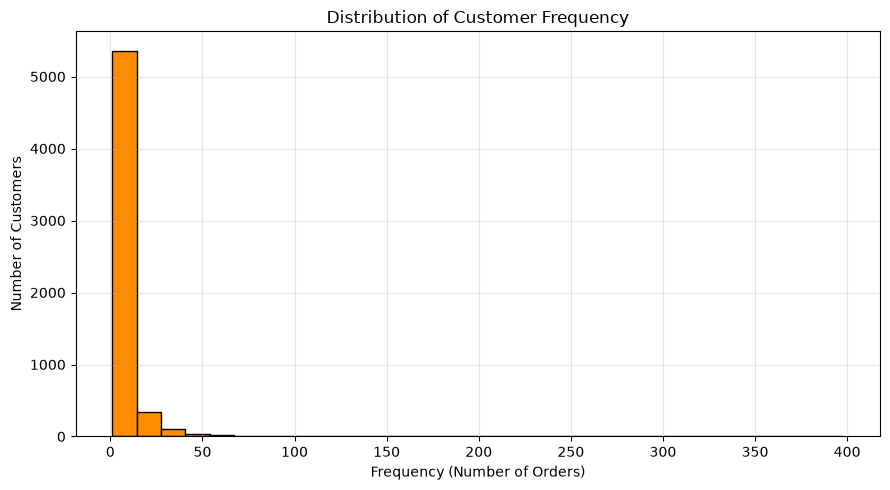

In [10]:
# 1. Frequency ka histogram banao
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Frequency'], bins=30, color='darkorange', edgecolor='black')
ax.set_xlabel('Frequency (Number of Orders)')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Customer Frequency')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observation Note: Haan, Frequency bhi Monetary ki tarah strongly right-skewed hoti hai! Iska matlab yeh hai ki zyadatar customers ki frequency bahut kam hoti hai (sirf 1 ya 2 orders), aur kuch hi aise loyal customers hote hain jinki frequency (orders) kaafi zyada hoti hai.